This document outlines how we will style our plots to maintain a consistent and professional appearance across all projects. It introduces our standard color palette, annotations, titles, subtitles, and credit lines—each contributing to a unified visual identity. The first section demonstrates how the general stylesheet enhances basic plots, followed by examples of additional styling techniques that further refine the presentation.

Processing standard ACS datasets...
Successfully processed and saved housing_age_clean.csv
Successfully processed and saved rent_clean.csv
Successfully processed and saved home_value_clean.csv
Successfully processed and saved rent_burden_clean.csv
Processing Poverty dataset...
Successfully processed and saved poverty_rate_clean.csv
Processing Income dataset...
Successfully processed and saved income_clean.csv
Processing Active Permits dataset...
Successfully processed and saved permits_2024_clean.csv
All files processed successfully!
Processing Neighborhood GeoDataFrame...
Successfully processed
Processing Permit GeoDataFrame...
Successfully processed
Processing Tracts GeoDataFrame...
Successfully processed
Processing variables for merging...
Successfully processed
Merging all DataFrames...
Successfully processed and saved merged.csv
Creating Need Index...
Successfully processed and saved plot.csv


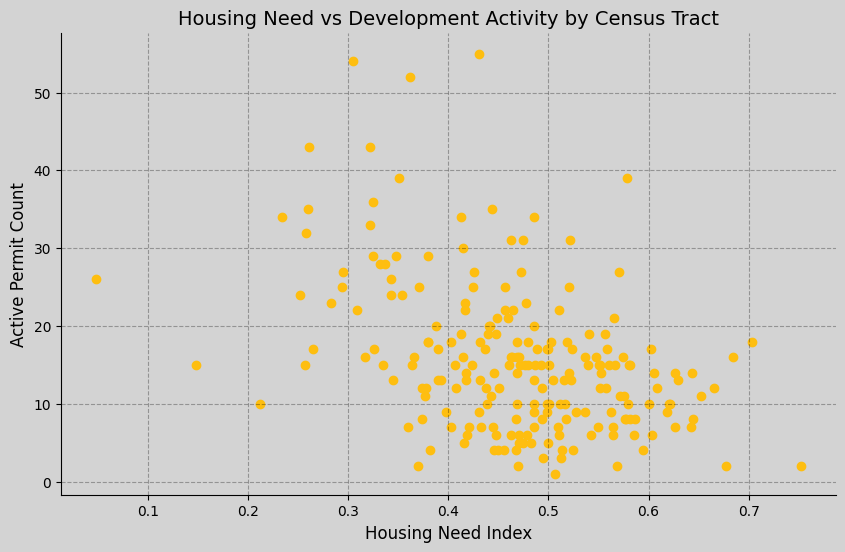

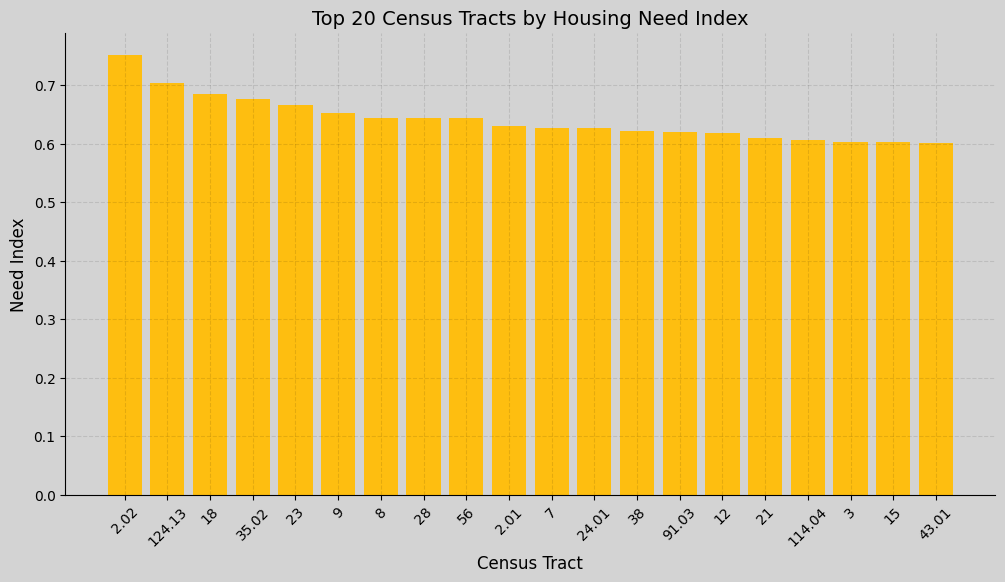

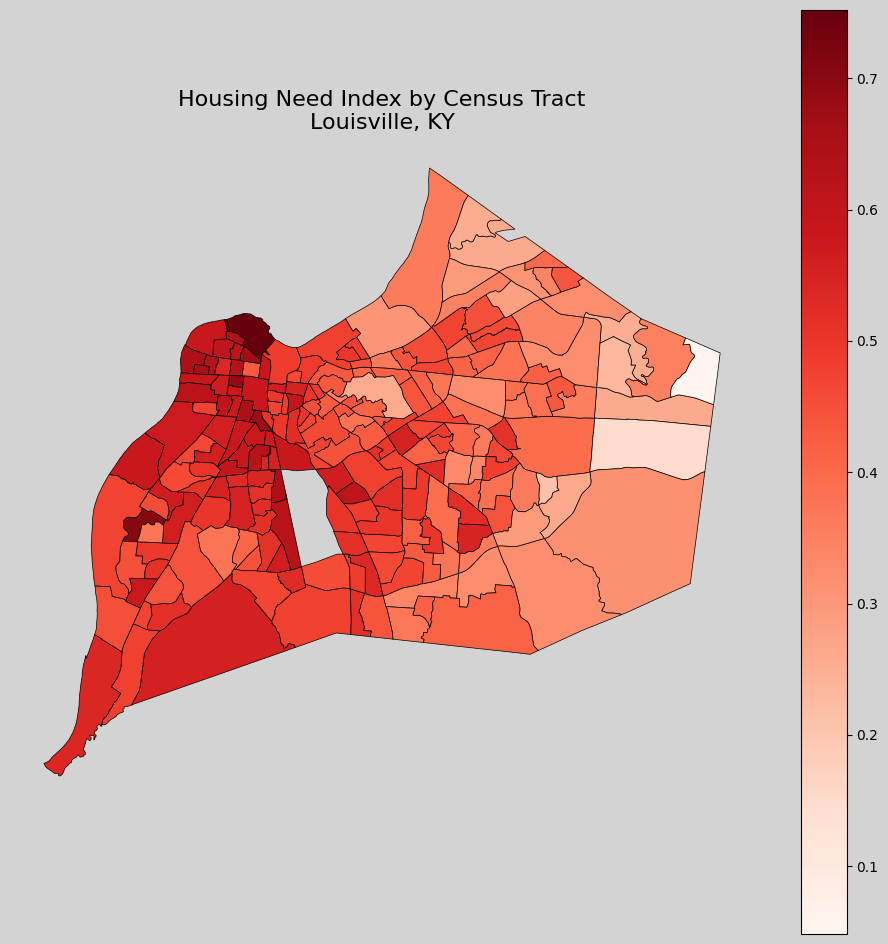

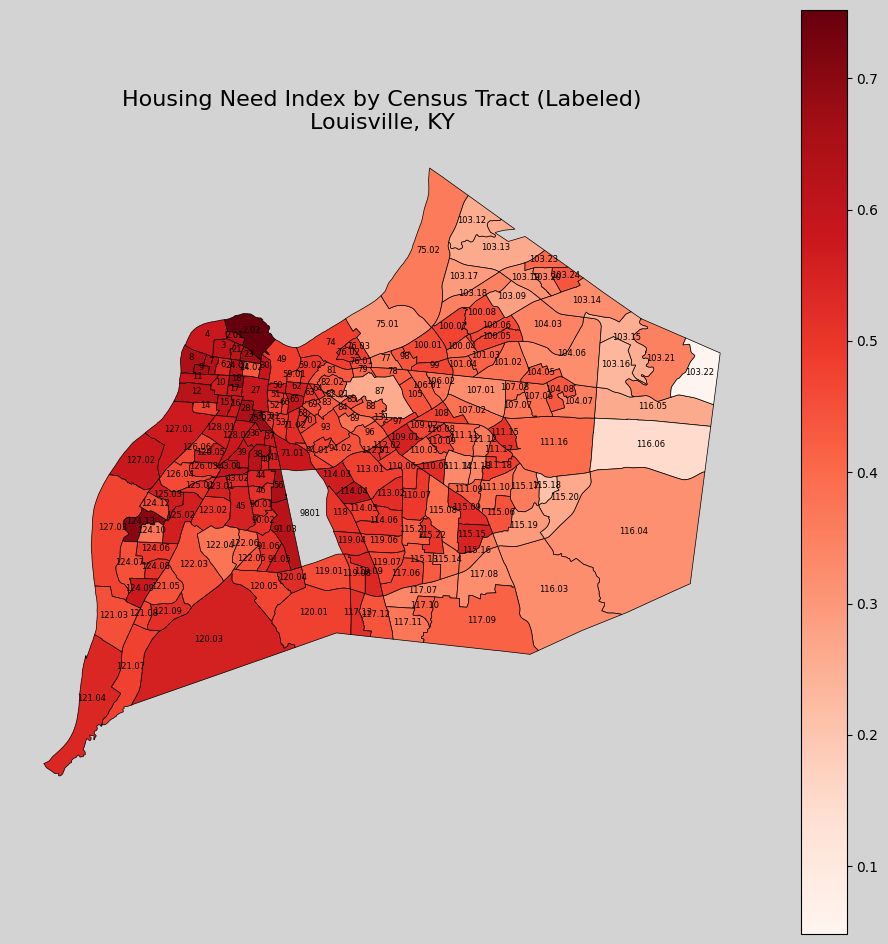

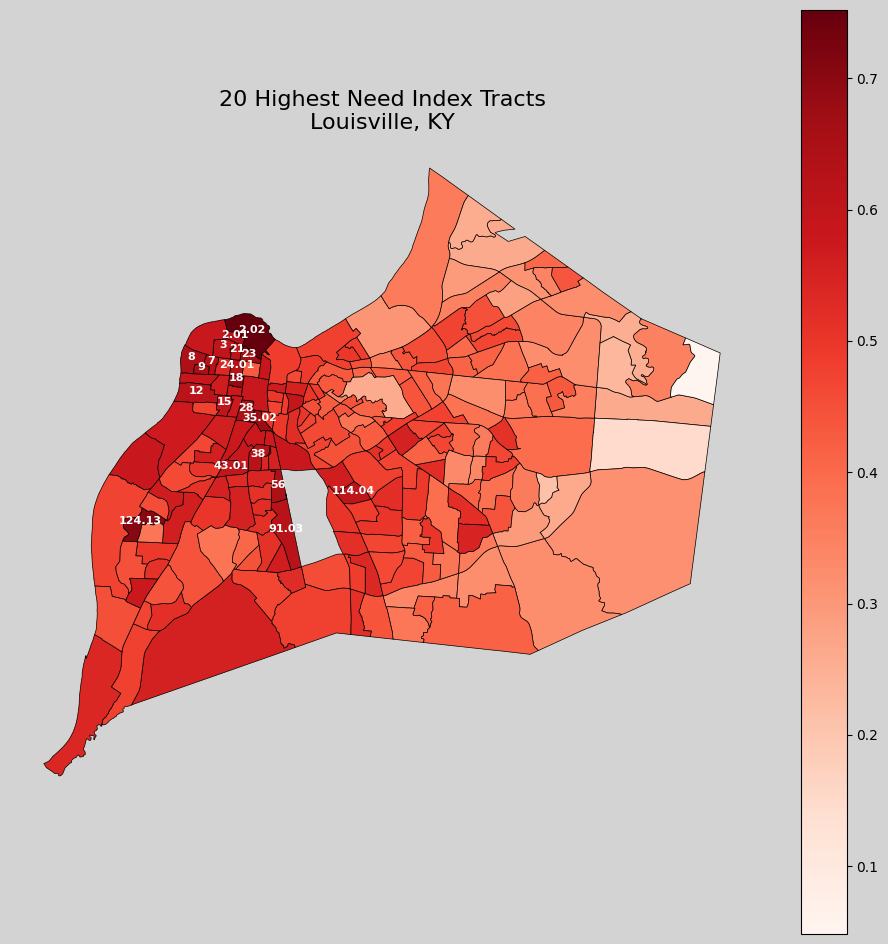

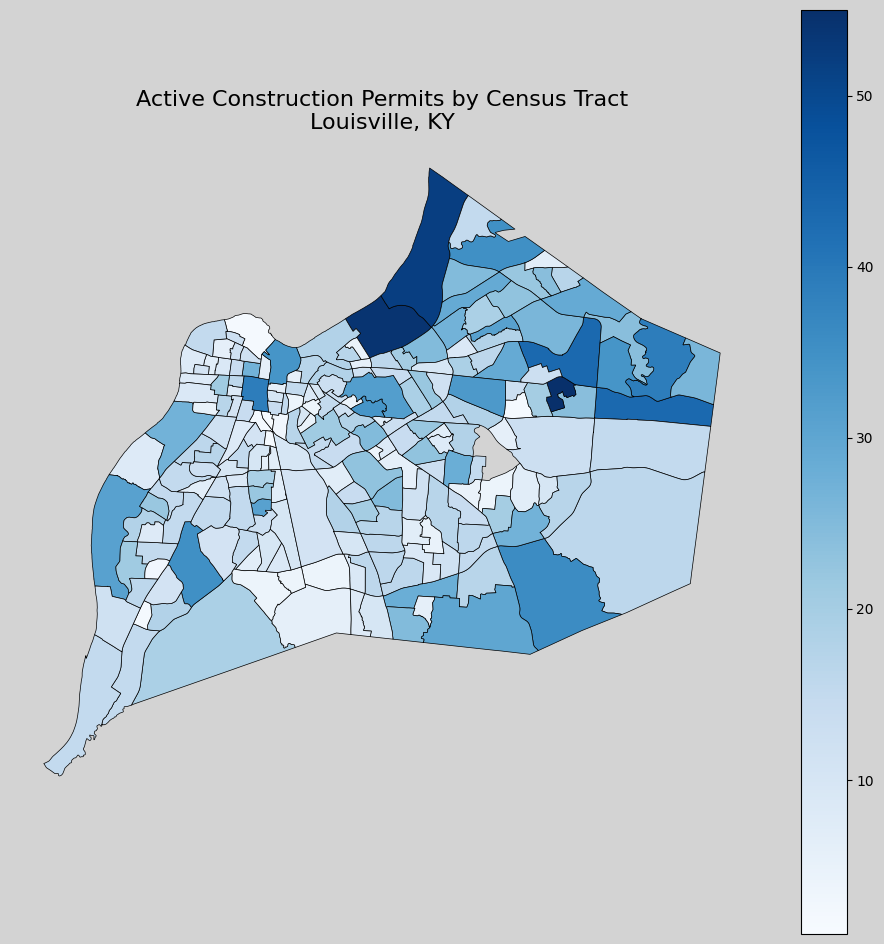

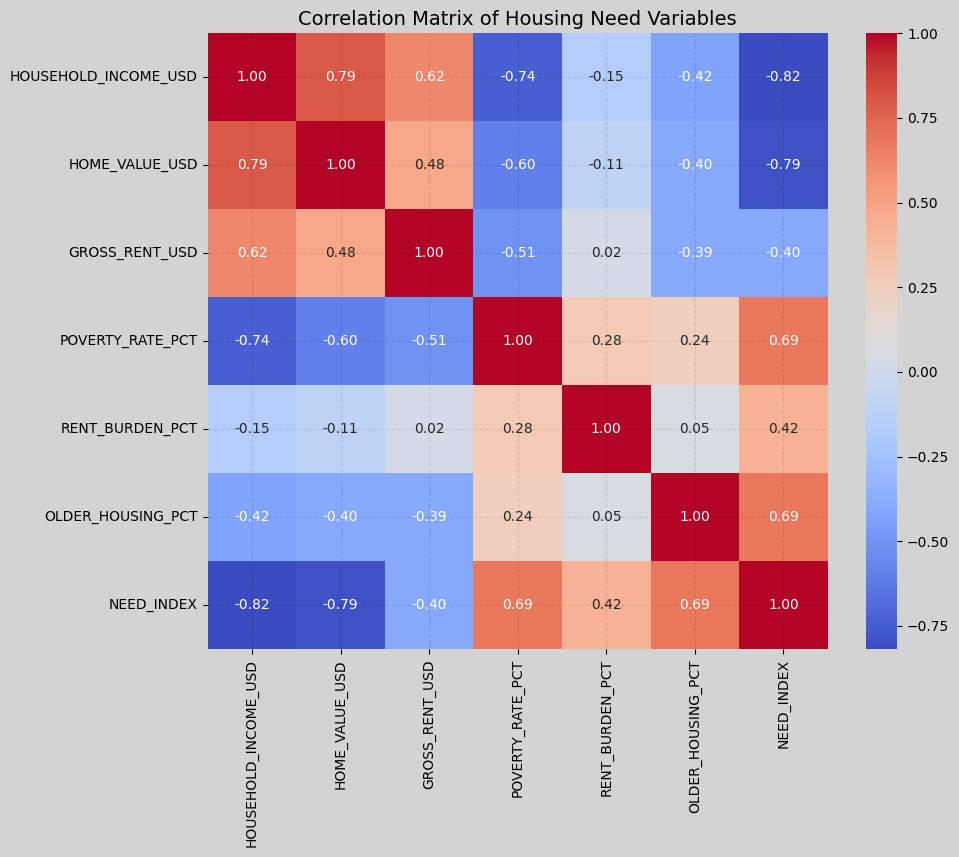


--- ✅ Copy the Markdown below and pasteit into a new markdown cell ---

# **Table of Contents**
* [**Table of Contents**](#**table-of-contents**)
  * [Imports](#imports)
  * [Clean Path](#clean-path)
  * [Clean Function](#clean-function)
* [1. Clean Standard ACS Datasets](#1.-clean-standard-acs-datasets)
* [2. Clean Poverty Data](#2.-clean-poverty-data)
* [3. Clean Income Data](#3.-clean-income-data)
* [4. Clean Active Permits](#4.-clean-active-permits)
* [5. GeoDataFrames](#5.-geodataframes)
    * [Permits](#permits)
    * [Tracts](#tracts)
* [6. Merge Prep](#6.-merge-prep)
* [7. Merging and Polishing](#7.-merging-and-polishing)
* [8. Need Index](#8.-need-index)
* [9. Visualizations](#9.-visualizations)
* [TOC Generator](#toc-generator)



In [15]:
%run curtis.ipynb

In [16]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import matplotlib.ticker as mticker
from pypalettes import load_cmap
from highlight_text import ax_text
from drawarrow import ax_arrow
from cycler import cycler

# sets the float format for pandas to display numbers without decimal places
pd.set_option('display.float_format', '{:,.0f}'.format)

# Style Settings

In [17]:
# Define your custom colors
colors = ['#FEBE10', '#1D1E9E', '#AD0000', '#000000', '#FFFFFF']

plt.rcParams.update({
    # Colors
    'axes.prop_cycle': cycler('color', colors),

    # Background
    'figure.facecolor': 'lightgrey',
    'axes.facecolor': 'lightgrey',
    'savefig.facecolor': 'lightgrey',

    # Grid
    'axes.grid': True,
    'grid.color': '#000000',
    'grid.alpha': 0.1,
    'grid.linestyle': '--',

    # Lines & markers
    'lines.linewidth': 2,
    'lines.markersize': 6,
    'lines.markeredgewidth': 0.5,

    # Axes & ticks
    'axes.edgecolor': '#000000',
    'axes.labelcolor': '#000000',
    'axes.labelsize': 12,
    'axes.titlesize': 14,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'xtick.color': '#000000',
    'ytick.color': '#000000',
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,

    # Legend
    'legend.frameon': False,
    'legend.fontsize': 10,
    'legend.loc': 'best',

    # Font
    'font.family': 'DejaVu Sans',
    'text.color': '#000000',

    # Savefig
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
})


## function for formatting numbers

In [18]:
# Create the formatter once
formatter = mticker.StrMethodFormatter("{x:,.0f}")

def apply_formatter(ax=None):
    """Automatically format numeric axes with commas, leave text/categorical axes alone."""
    if ax is None:
        ax = plt.gca()
    
    # Format x-axis only if tick labels are numbers
    x_labels = [lbl.get_text() for lbl in ax.get_xticklabels()]
    if all(_is_number(lbl) for lbl in x_labels):
        ax.xaxis.set_major_formatter(formatter)
    
    # Format y-axis only if tick labels are numbers
    y_labels = [lbl.get_text() for lbl in ax.get_yticklabels()]
    if all(_is_number(lbl) for lbl in y_labels):
        ax.yaxis.set_major_formatter(formatter)

def _is_number(s):
    """Helper to check if string can be converted to float."""
    try:
        float(s.replace(',', ''))  # remove commas if already formatted
        return True
    except ValueError:
        return False

# Visualizations

In [19]:
# Geometry = polygon
map_df = gdf_tracts.merge(df_plot, on = "GEOID", how = "left")

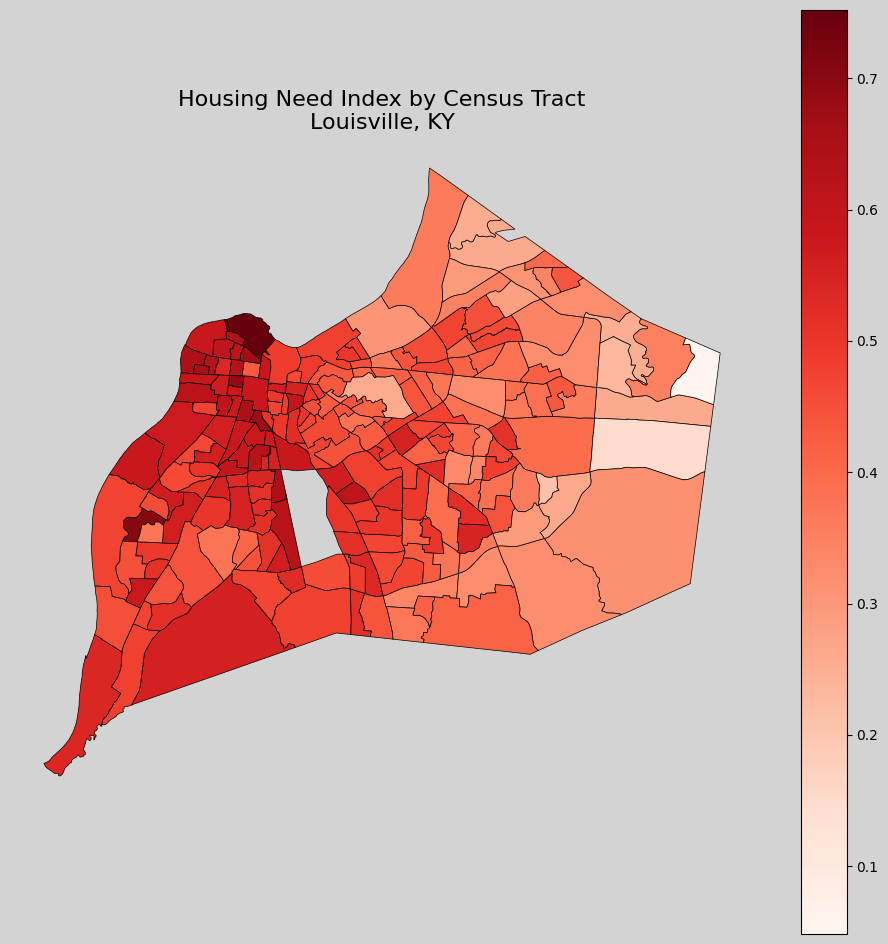

In [53]:
# Housing Need Choropleth 
fig, ax = plt.subplots(figsize=(12, 12))
# Plot tract polygons colored by NEED_INDEX
map_df.plot(
    column="NEED_INDEX",
    cmap="Reds",
    linewidth=0.5,
    edgecolor="black",
    legend=True,
    ax=ax
)

ax.set_title(
    "Housing Need Index by Census Tract\nLouisville, KY",
    fontsize=16
)

ax.axis("off")

plt.savefig(FIGURES_DIR / "need_choropleth.png", dpi=300, bbox_inches="tight")

plt.show()

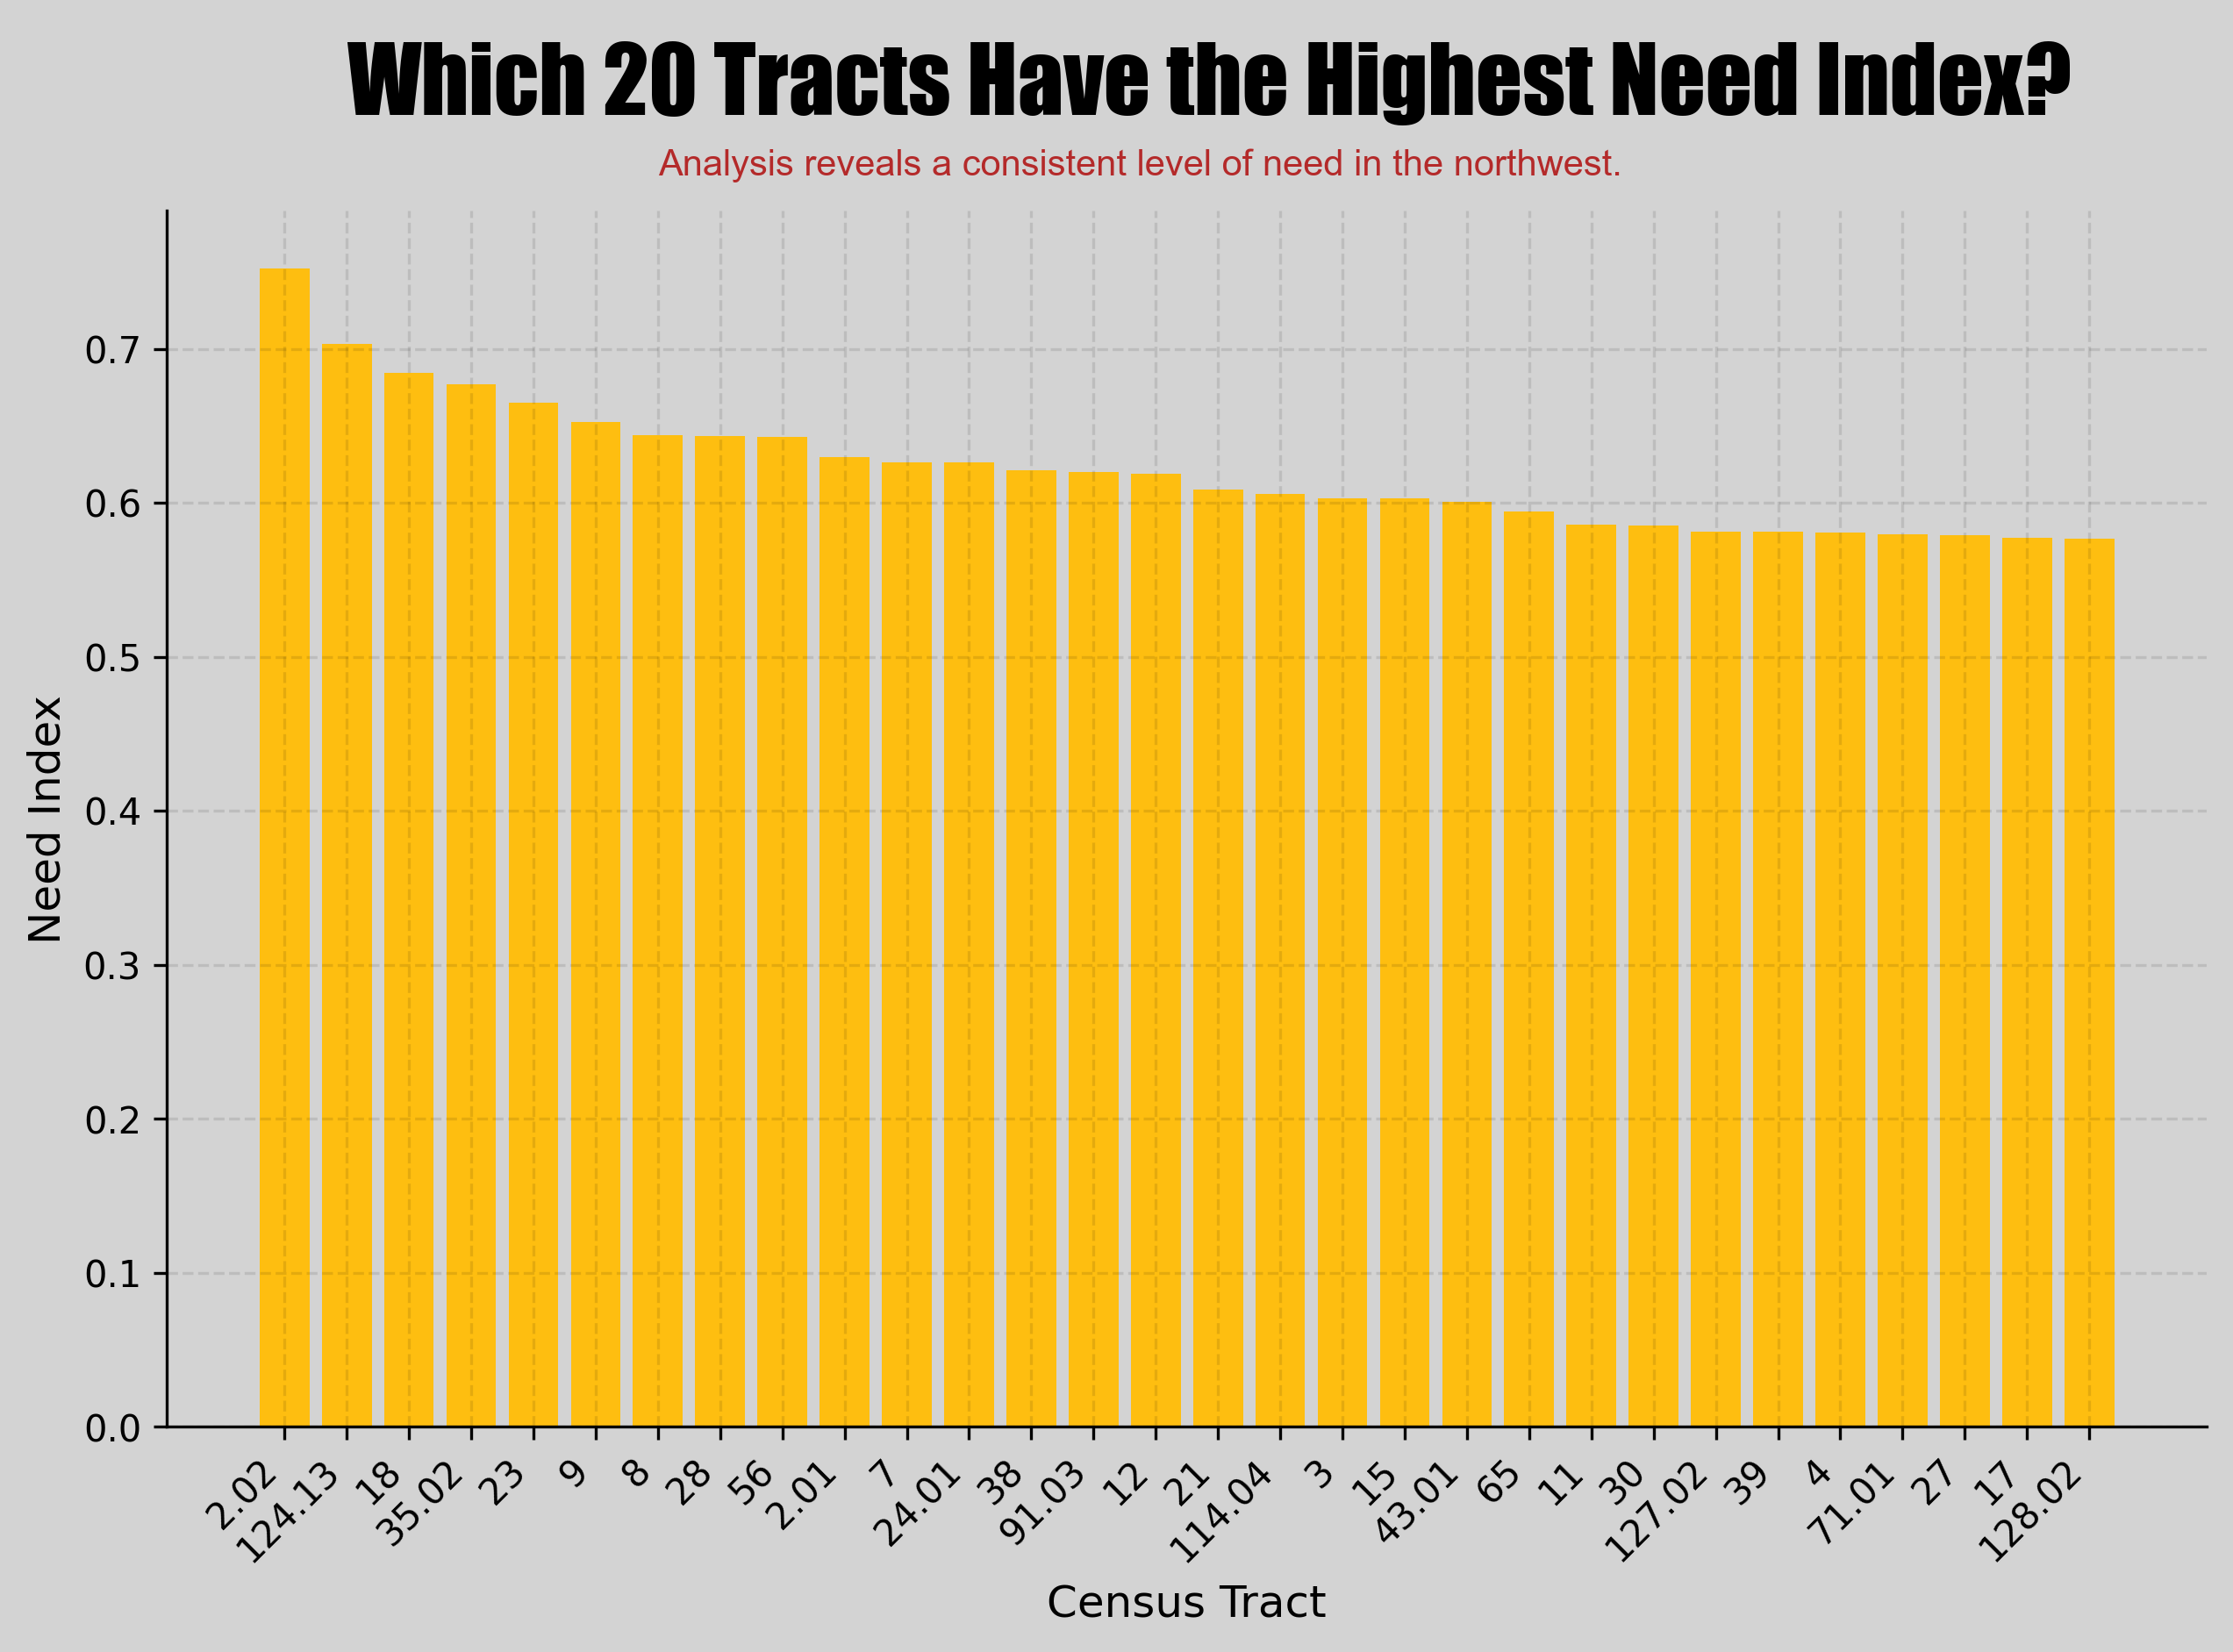

In [51]:
top_tracts = (
    map_df[['TRACT', 'NEED_INDEX']]
    .sort_values(by='NEED_INDEX', ascending=False)
    .head(30)
)

plt.figure(figsize=(10,6), dpi = 300)
ax = plt.gca()

# Plot type
plt.bar(top_tracts['TRACT'].astype(str), top_tracts['NEED_INDEX'])

# Labels
plt.xlabel('Census Tract')
plt.ylabel('Need Index')
plt.xticks(rotation=45, ha ="right")


# Title (added space for larger figure)
s = "Which 20 Tracts Have the Highest Need Index?"
ax_text(x=1, y=.9, s=s, fontfamily='impact', size=25, ha="left")

# Additional subtitle
s = "Analysis reveals a consistent level of need in the northwest."
ax_text(x=6, y=0.83, s=s, fontfamily='arial', size=10, ha="left", color="#AD0000", alpha=0.8)


plt.savefig(FIGURES_DIR / "highest_need_bar_chart.png", bbox_inches="tight")

plt.show()

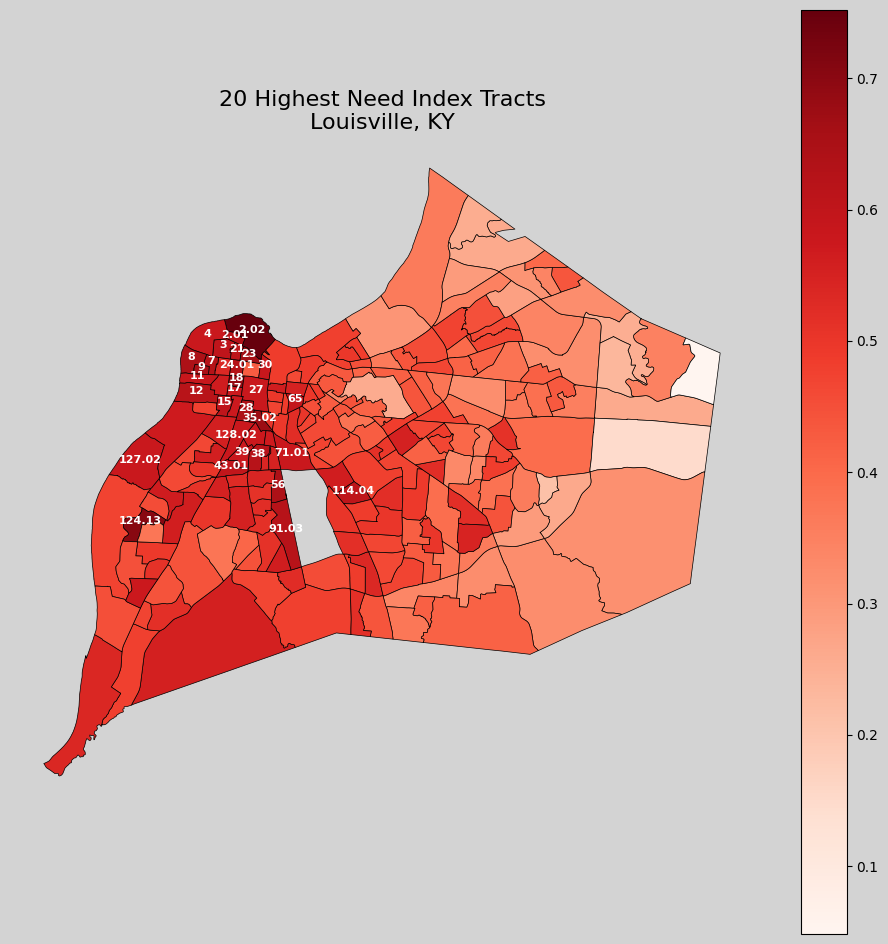

In [54]:
# Housing Need Choropleth 

top_tracts = map_df.nlargest(30, "NEED_INDEX")

fig, ax = plt.subplots(figsize=(12, 12))

# Plot tract polygons colored by NEED_INDEX
map_df.plot(
    column="NEED_INDEX",
    cmap="Reds",
    linewidth=0.5,
    edgecolor="black",
    legend=True,
    ax=ax
)

for idx, row in top_tracts.iterrows():
    centroid = row.geometry.centroid

    ax.text(
        centroid.x,
        centroid.y,
        row["TRACT"],
        fontsize=8,
        fontweight="bold",
        color='white',
        ha="center"
    )

ax.set_title(
    "20 Highest Need Index Tracts\nLouisville, KY",
    fontsize=16
)

ax.axis("off")

plt.savefig(FIGURES_DIR / "highest_need_choropleth_with_labels.png", dpi=300, bbox_inches="tight")

plt.show()

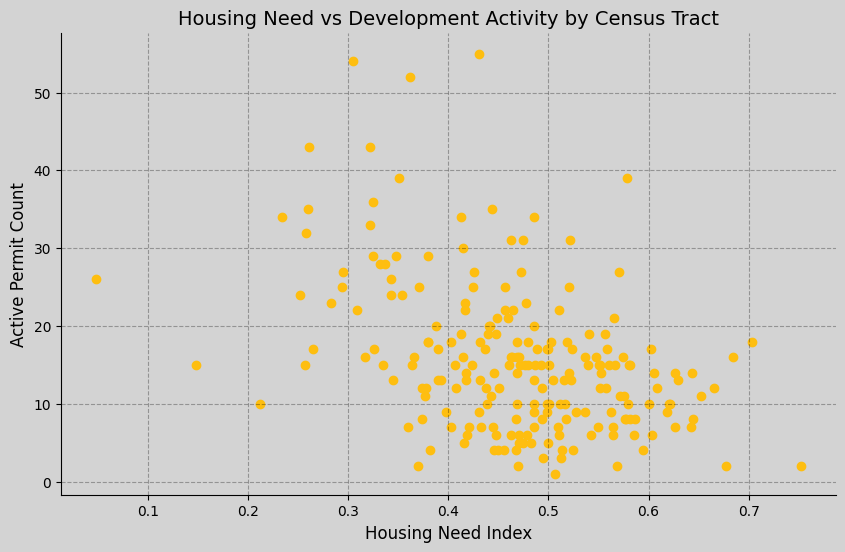

In [20]:
# Compare permit count vs need index
plt.figure(figsize=(10, 6))
plt.scatter(df_plot["NEED_INDEX"], df_plot["PERMIT_COUNT"])
plt.xlabel("Housing Need Index")
plt.ylabel("Active Permit Count")
plt.title("Housing Need vs Development Activity by Census Tract")
plt.grid(alpha=0.3)

plt.savefig(FIGURES_DIR / "need_permits_scatter_plot.png", dpi=300, bbox_inches="tight")
plt.show()

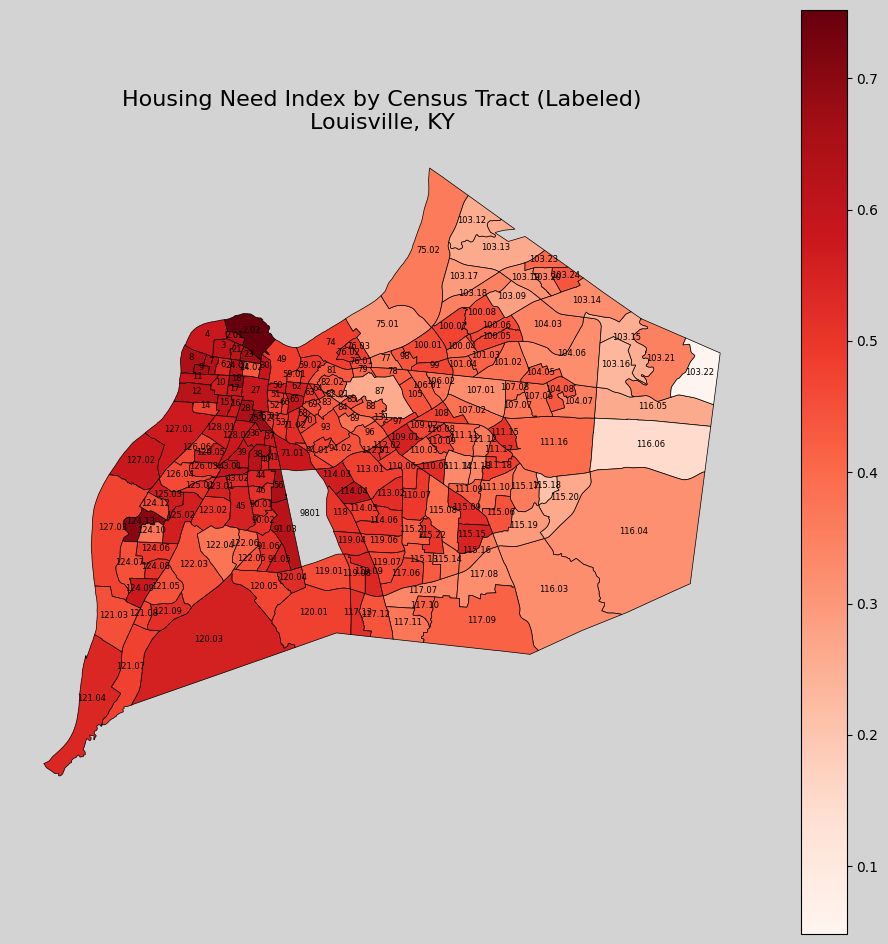

In [10]:
# Housing Need Choropleth 

fig, ax = plt.subplots(figsize=(12, 12))

# Plot tract polygons colored by NEED_INDEX
map_df.plot(
    column="NEED_INDEX",
    cmap="Reds",
    linewidth=0.5,
    edgecolor="black",
    legend=True,
    ax=ax
)

# Add tract labels
for idx, row in map_df.iterrows():
    centroid = row.geometry.centroid

    ax.text(
        centroid.x,
        centroid.y,
        row["TRACT"],
        fontsize=6,
        ha="center"
    )

ax.set_title(
    "Housing Need Index by Census Tract (Labeled)\nLouisville, KY",
    fontsize=16
)

ax.axis("off")

plt.savefig(FIGURES_DIR / "need_choropleth_with_tract_labels.png", dpi=300, bbox_inches="tight")

plt.show()

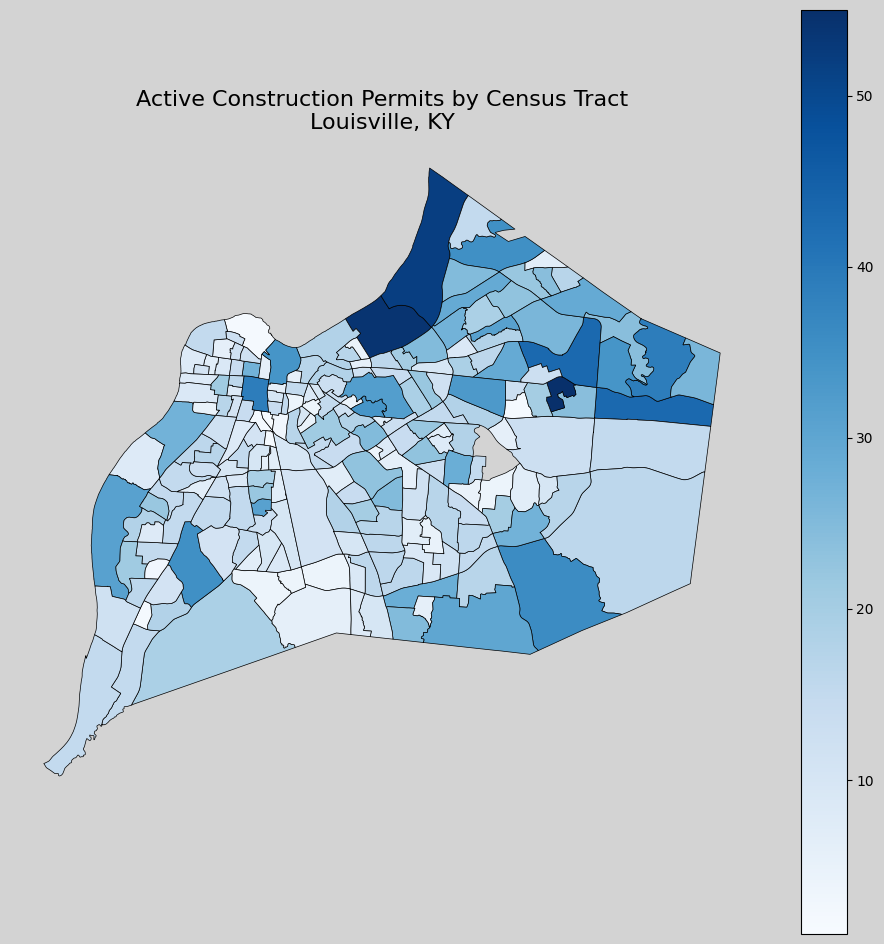

In [12]:
# Permit Choropleth

fig, ax = plt.subplots(figsize=(12, 12))

map_df.plot(
    column="PERMIT_COUNT",
    cmap="Blues",
    linewidth=0.5,
    edgecolor="black",
    legend=True,
    ax=ax
)

ax.set_title(
    "Active Construction Permits by Census Tract\nLouisville, KY",
    fontsize=16
)

ax.axis("off")

plt.savefig(FIGURES_DIR / "permit_count_choropleth.png", dpi=300, bbox_inches="tight")

plt.show()

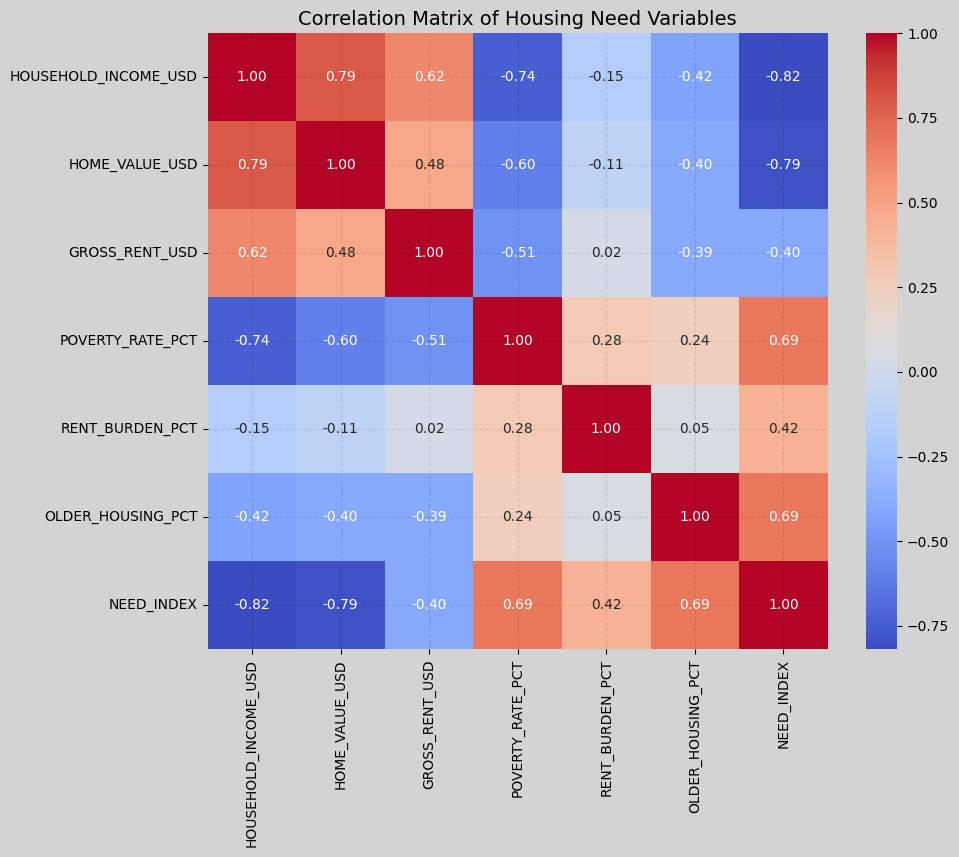

In [13]:
corr_cols = [
    'HOUSEHOLD_INCOME_USD',
    'HOME_VALUE_USD',
    'GROSS_RENT_USD',
    'POVERTY_RATE_PCT',
    'RENT_BURDEN_PCT',
    'OLDER_HOUSING_PCT',
    'NEED_INDEX'
]

corr_matrix = map_df[corr_cols].corr()

plt.figure(figsize=(10,8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Matrix of Housing Need Variables')

plt.savefig(FIGURES_DIR / "need_correlation_matrix.png", dpi=300, bbox_inches="tight")

plt.show()